# Analyse Climat — Station Climatique *Kairouan Sbikha* (DGACTA)

Ce notebook réalise une **analyse BI** simple et propre à partir de 4 fichiers CSV :
- `data/environnement.csv` (capteur d'environnement : température, humidité relative, vent, pression…)
- `data/pluviometrie.csv` (pluie)
- `data/humidite_sol_10cm.csv`
- `data/humidite_sol_30cm.csv`

✅ Objectifs :
1. Charger + nettoyer les données (dates, valeurs, unités, doublons).
2. Produire des **KPI** (min/max/moy, pluie totale, comparaison 10cm vs 30cm, etc.).
3. Générer des **graphiques lisibles** (séries temporelles + agrégations journalières).

---
## 0) Pré-requis : structure du dossier

Place tes fichiers dans ce dossier :
```
climat-kairouan/
  data/
    environnement.csv
    pluviometrie.csv
    humidite_sol_10cm.csv
    humidite_sol_30cm.csv
  output/
```


In [1]:
# 0) Packages + options
Sys.setenv(TZ = "UTC")

suppressPackageStartupMessages({
  library(tidyverse)
  library(lubridate)
  library(janitor)
  library(scales)
})

dir.create("output/graphs", recursive = TRUE, showWarnings = FALSE)
dir.create("output/clean",  recursive = TRUE, showWarnings = FALSE)


## 1) Chargement des données (robuste)

On lit chaque CSV puis on standardise les colonnes :
- `date` (POSIXct)
- `nom_fr` (nom du paramètre en français)
- `unite` (unité)
- `valeur` (numérique)

> ⚠️ Les fichiers open-data peuvent avoir des variations de noms de colonnes, donc on nettoie d’abord (`clean_names()`).


In [2]:
read_sensor_csv <- function(path) {
  df <- readr::read_csv(path, show_col_types = FALSE) %>%
    janitor::clean_names()

  date_col <- intersect(names(df), c("date", "datetime", "horodatage", "time", "timestamp"))[1]
  val_col  <- intersect(names(df), c("valeur", "value", "mesure", "val"))[1]
  nom_fr_col <- intersect(names(df), c("nom_fr", "nom", "capteur", "parametre", "parametre_fr"))[1]
  nom_ar_col <- intersect(names(df), c("nom_ar", "nomar"))[1]
  unite_col  <- intersect(names(df), c("unite", "unit"))[1]

  if (is.na(date_col)) stop(paste("❌ Colonne date introuvable dans:", path))
  if (is.na(val_col))  stop(paste("❌ Colonne valeur introuvable dans:", path))

  df2 <- df %>%
    transmute(
      date_raw = .data[[date_col]],
      nom_fr   = if (!is.na(nom_fr_col)) as.character(.data[[nom_fr_col]]) else NA_character_,
      nom_ar   = if (!is.na(nom_ar_col)) as.character(.data[[nom_ar_col]]) else NA_character_,
      unite    = if (!is.na(unite_col))  as.character(.data[[unite_col]])  else NA_character_,
      valeur   = suppressWarnings(as.numeric(.data[[val_col]]))
    ) %>%
    mutate(
      date = suppressWarnings(ymd_hms(date_raw, quiet = TRUE)),
      date = if_else(is.na(date), suppressWarnings(dmy_hms(date_raw, quiet = TRUE)), date),
      date = if_else(is.na(date), suppressWarnings(ymd(date_raw, quiet = TRUE) %>% as.POSIXct()), date)
    ) %>%
    select(date, nom_fr, nom_ar, unite, valeur) %>%
    filter(!is.na(date), !is.na(valeur))

  df2
}

# Chemins
path_env  <- "data/environnement.csv"
path_plui <- "data/pluviometrie.csv"
path_h10  <- "data/humidite_sol_10cm.csv"
path_h30  <- "data/humidite_sol_30cm.csv"

env  <- read_sensor_csv(path_env)
plui <- read_sensor_csv(path_plui)
h10  <- read_sensor_csv(path_h10)
h30  <- read_sensor_csv(path_h30)

tibble(
  dataset = c("env", "pluie", "hum_sol_10cm", "hum_sol_30cm"),
  n = c(nrow(env), nrow(plui), nrow(h10), nrow(h30)),
  date_min = c(min(env$date), min(plui$date), min(h10$date), min(h30$date)),
  date_max = c(max(env$date), max(plui$date), max(h10$date), max(h30$date))
)


Warning message in format.POSIXlt(as.POSIXlt(x, tz), format, usetz, ...):
"unknown timezone 'UTC'"
Warning message in format.POSIXlt(as.POSIXlt(x, tz), format, usetz, ...):
"unknown timezone 'GMT'"
Warning message in format.POSIXlt(as.POSIXlt(x, tz), format, usetz, ...):
"unknown timezone 'America/New_York'"
Warning message in as.POSIXlt.POSIXct(x, tz):
"unknown timezone 'Africa/Tunis'"
Warning message in as.POSIXlt.POSIXct(x, tz):
"unknown timezone 'GMT'"
Warning message in as.POSIXlt.POSIXct(x, tz):
"unknown timezone 'America/New_York'"
Warning message in as.POSIXlt.POSIXct(x, tz):
"unknown timezone 'Africa/Tunis'"
Warning message in as.POSIXlt.POSIXct(x, tz):
"unknown timezone 'GMT'"
Warning message in as.POSIXlt.POSIXct(x, tz):
"unknown timezone 'America/New_York'"
Warning message in as.POSIXlt.POSIXct(x, tz):
"unknown timezone 'Africa/Tunis'"
Warning message in as.POSIXlt.POSIXct(x, tz):
"unknown timezone 'GMT'"
Warning message in as.POSIXlt.POSIXct(x, tz):
"unknown timezone 'Amer

dataset,n,date_min,date_max
<chr>,<int>,<dttm>,<dttm>
env,1287,2025-12-03 01:00:00,2025-12-16 05:00:00
pluie,12,2025-12-04 05:00:00,2025-12-16 03:00:00
hum_sol_10cm,432,2025-12-03 01:00:00,2025-12-16 05:00:00
hum_sol_30cm,432,2025-12-03 01:00:00,2025-12-16 05:00:00


## 2) Vérifier les paramètres disponibles (important pour éviter les graphes vides)

Ici on affiche les valeurs distinctes de `nom_fr` et `unite`.


In [3]:
env %>% distinct(nom_fr, unite) %>% arrange(nom_fr) %>% print(n = 60)

Warning message in as.POSIXlt.POSIXct(Sys.time(), "UTC"):
"unknown timezone 'Africa/Tunis'"
Warning message in as.POSIXlt.POSIXct(Sys.time(), "UTC"):
"unknown timezone 'GMT'"
Warning message in as.POSIXlt.POSIXct(Sys.time(), "UTC"):
"unknown timezone 'America/New_York'"


# A tibble: 9 × 2
  nom_fr                         unite
  <chr>                          <chr>
1 Direction du vent              Deg  
2 Humidité relative              %    
3 Point de Rosée                 °c   
4 Pression atmosphérique         hPa  
5 Rayonnement solaire            W/m² 
6 Température                    °c   
7 Vitesse du vent                m/s  
8 Évapotranspiration Horaire     mm/h 
9 Évapotranspiration journalière mm/j 


In [4]:
plui %>% distinct(nom_fr, unite) %>% arrange(nom_fr) %>% print(n = 60)

Warning message in as.POSIXlt.POSIXct(Sys.time(), "UTC"):
"unknown timezone 'Africa/Tunis'"
Warning message in as.POSIXlt.POSIXct(Sys.time(), "UTC"):
"unknown timezone 'GMT'"
Warning message in as.POSIXlt.POSIXct(Sys.time(), "UTC"):
"unknown timezone 'America/New_York'"


# A tibble: 3 × 2
  nom_fr             unite
  <chr>              <chr>
1 Intensité de Pluie mm/h 
2 Pluie Totale       mm   
3 Pluie quotidienne  mm   


In [5]:
h10 %>% distinct(nom_fr, unite) %>% arrange(nom_fr) %>% print(n = 60)

Warning message in as.POSIXlt.POSIXct(Sys.time(), "UTC"):
"unknown timezone 'Africa/Tunis'"
Warning message in as.POSIXlt.POSIXct(Sys.time(), "UTC"):
"unknown timezone 'GMT'"
Warning message in as.POSIXlt.POSIXct(Sys.time(), "UTC"):
"unknown timezone 'America/New_York'"


# A tibble: 3 × 2
  nom_fr                     unite
  <chr>                      <chr>
1 Contenu volumétrique d'eau %    
2 L'humidité du sol          mV   
3 Température                °c   


In [6]:
h30 %>% distinct(nom_fr, unite) %>% arrange(nom_fr) %>% print(n = 60)

Warning message in as.POSIXlt.POSIXct(Sys.time(), "UTC"):
"unknown timezone 'Africa/Tunis'"
Warning message in as.POSIXlt.POSIXct(Sys.time(), "UTC"):
"unknown timezone 'GMT'"
Warning message in as.POSIXlt.POSIXct(Sys.time(), "UTC"):
"unknown timezone 'America/New_York'"


# A tibble: 3 × 2
  nom_fr                     unite
  <chr>                      <chr>
1 Contenu volumétrique d'eau %    
2 L'humidité du sol          mV   
3 Température                °c   


## 3) Sélection robuste d'un paramètre

On récupère les lignes dont `nom_fr` contient des mots-clés (insensible à la casse).
Si tes libellés sont différents, adapte les mots-clés.


In [7]:
pick_param <- function(df, keywords) {
  pattern <- paste(keywords, collapse = "|")
  df %>%
    mutate(nom_fr_l = str_to_lower(replace_na(nom_fr, ""))) %>%
    filter(str_detect(nom_fr_l, str_to_lower(pattern))) %>%
    select(-nom_fr_l)
}

temp_df   <- pick_param(env,  c("temp"))
humrel_df <- pick_param(env,  c("humid"))

list(
  temp_rows = nrow(temp_df),
  humrel_rows = nrow(humrel_df)
)


Warning message in as.POSIXlt.POSIXct(Sys.time(), "UTC"):
"unknown timezone 'Africa/Tunis'"
Warning message in as.POSIXlt.POSIXct(Sys.time(), "UTC"):
"unknown timezone 'GMT'"
Warning message in as.POSIXlt.POSIXct(Sys.time(), "UTC"):
"unknown timezone 'America/New_York'"


$temp_rows
[1] 143

$humrel_rows
[1] 143

## 4) KPI (indicateurs)

- Température : min / max / moyenne  
- Humidité relative : min / max / moyenne  
- Pluie : total + nombre de jours de pluie  
- Humidité du sol : statistiques 10cm vs 30cm  


In [8]:
kpi_temp <- temp_df %>% summarise(
  n = n(),
  temp_min = min(valeur, na.rm = TRUE),
  temp_max = max(valeur, na.rm = TRUE),
  temp_mean = mean(valeur, na.rm = TRUE)
)

kpi_humrel <- humrel_df %>% summarise(
  n = n(),
  hum_min = min(valeur, na.rm = TRUE),
  hum_max = max(valeur, na.rm = TRUE),
  hum_mean = mean(valeur, na.rm = TRUE)
)

plui_jour <- plui %>%
  mutate(jour = as.Date(date)) %>%
  group_by(jour) %>%
  summarise(pluie_total = sum(valeur, na.rm = TRUE), .groups = "drop")

kpi_pluie <- plui_jour %>% summarise(
  jours = n(),
  jours_pluie = sum(pluie_total > 0, na.rm = TRUE),
  pluie_totale = sum(pluie_total, na.rm = TRUE),
  pluie_moy_jour = mean(pluie_total, na.rm = TRUE)
)

kpi_sol <- tibble(
  profondeur = c("10cm", "30cm"),
  n = c(nrow(h10), nrow(h30)),
  min = c(min(h10$valeur, na.rm = TRUE), min(h30$valeur, na.rm = TRUE)),
  mean = c(mean(h10$valeur, na.rm = TRUE), mean(h30$valeur, na.rm = TRUE)),
  max = c(max(h10$valeur, na.rm = TRUE), max(h30$valeur, na.rm = TRUE))
)

kpi_temp
kpi_humrel
kpi_pluie
kpi_sol


Warning message in as.POSIXlt.POSIXct(Sys.time(), "UTC"):
"unknown timezone 'Africa/Tunis'"
Warning message in as.POSIXlt.POSIXct(Sys.time(), "UTC"):
"unknown timezone 'GMT'"
Warning message in as.POSIXlt.POSIXct(Sys.time(), "UTC"):
"unknown timezone 'America/New_York'"


n,temp_min,temp_max,temp_mean
<int>,<dbl>,<dbl>,<dbl>
143,8.4,22.3,14.42657


Warning message in as.POSIXlt.POSIXct(Sys.time(), "UTC"):
"unknown timezone 'Africa/Tunis'"
Warning message in as.POSIXlt.POSIXct(Sys.time(), "UTC"):
"unknown timezone 'GMT'"
Warning message in as.POSIXlt.POSIXct(Sys.time(), "UTC"):
"unknown timezone 'America/New_York'"


n,hum_min,hum_max,hum_mean
<int>,<dbl>,<dbl>,<dbl>
143,35.6,100,69.28252


Warning message in as.POSIXlt.POSIXct(Sys.time(), "UTC"):
"unknown timezone 'Africa/Tunis'"
Warning message in as.POSIXlt.POSIXct(Sys.time(), "UTC"):
"unknown timezone 'GMT'"
Warning message in as.POSIXlt.POSIXct(Sys.time(), "UTC"):
"unknown timezone 'America/New_York'"


jours,jours_pluie,pluie_totale,pluie_moy_jour
<int>,<int>,<dbl>,<dbl>
3,3,4071,1357


Warning message in as.POSIXlt.POSIXct(Sys.time(), "UTC"):
"unknown timezone 'Africa/Tunis'"
Warning message in as.POSIXlt.POSIXct(Sys.time(), "UTC"):
"unknown timezone 'GMT'"
Warning message in as.POSIXlt.POSIXct(Sys.time(), "UTC"):
"unknown timezone 'America/New_York'"


profondeur,n,min,mean,max
<chr>,<int>,<dbl>,<dbl>,<dbl>
10cm,432,7.1,194.7308,567.1
30cm,432,8.0,201.4991,583.2


## 5) Graphiques (corrigés)

> 🔥 Règle pour éviter les graphes vides :  
On **agrège** souvent en *journée* (moyenne journalière) car les mesures 15 minutes peuvent être très nombreuses ou très plates selon les valeurs.

### 5.1 Température : 15 min + moyenne journalière


Warning message in as.POSIXlt.POSIXct(x):
"unknown timezone 'Africa/Tunis'"
Warning message in as.POSIXlt.POSIXct(x):
"unknown timezone 'GMT'"
Warning message in as.POSIXlt.POSIXct(x):
"unknown timezone 'America/New_York'"
Warning message in as.POSIXct.POSIXlt(from):
"unknown timezone 'Africa/Tunis'"
Warning message in as.POSIXct.POSIXlt(from):
"unknown timezone 'GMT'"
Warning message in as.POSIXct.POSIXlt(from):
"unknown timezone 'America/New_York'"
Warning message in as.POSIXct.POSIXlt(from):
"unknown timezone 'Africa/Tunis'"
Warning message in as.POSIXct.POSIXlt(from):
"unknown timezone 'GMT'"
Warning message in as.POSIXct.POSIXlt(from):
"unknown timezone 'America/New_York'"
Warning message in as.POSIXct.POSIXlt(r1):
"unknown timezone 'Africa/Tunis'"
Warning message in as.POSIXct.POSIXlt(r1):
"unknown timezone 'GMT'"
Warning message in as.POSIXct.POSIXlt(r1):
"unknown timezone 'America/New_York'"
Warning message in as.POSIXlt.POSIXct(from):
"unknown timezone 'Africa/Tunis'"
Warning 

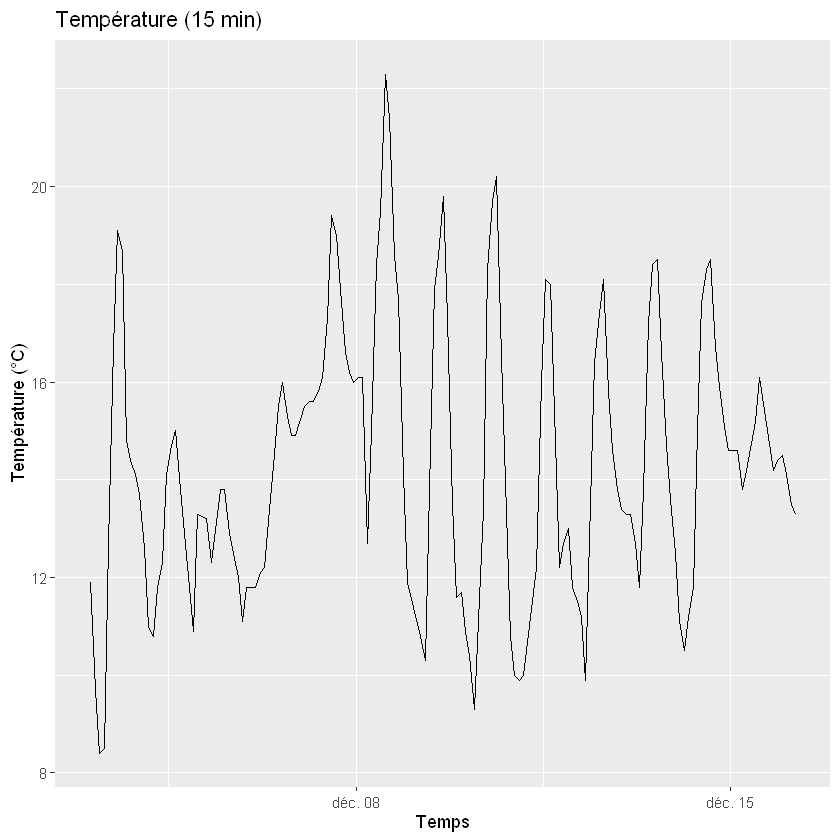

Warning message in as.POSIXlt.POSIXct(x):
"unknown timezone 'Africa/Tunis'"
Warning message in as.POSIXlt.POSIXct(x):
"unknown timezone 'GMT'"
Warning message in as.POSIXlt.POSIXct(x):
"unknown timezone 'America/New_York'"
Warning message in as.POSIXct.POSIXlt(from):
"unknown timezone 'Africa/Tunis'"
Warning message in as.POSIXct.POSIXlt(from):
"unknown timezone 'GMT'"
Warning message in as.POSIXct.POSIXlt(from):
"unknown timezone 'America/New_York'"
Warning message in as.POSIXct.POSIXlt(from):
"unknown timezone 'Africa/Tunis'"
Warning message in as.POSIXct.POSIXlt(from):
"unknown timezone 'GMT'"
Warning message in as.POSIXct.POSIXlt(from):
"unknown timezone 'America/New_York'"
Warning message in as.POSIXct.POSIXlt(r1):
"unknown timezone 'Africa/Tunis'"
Warning message in as.POSIXct.POSIXlt(r1):
"unknown timezone 'GMT'"
Warning message in as.POSIXct.POSIXlt(r1):
"unknown timezone 'America/New_York'"
Warning message in as.POSIXlt.POSIXct(from):
"unknown timezone 'Africa/Tunis'"
Warning 

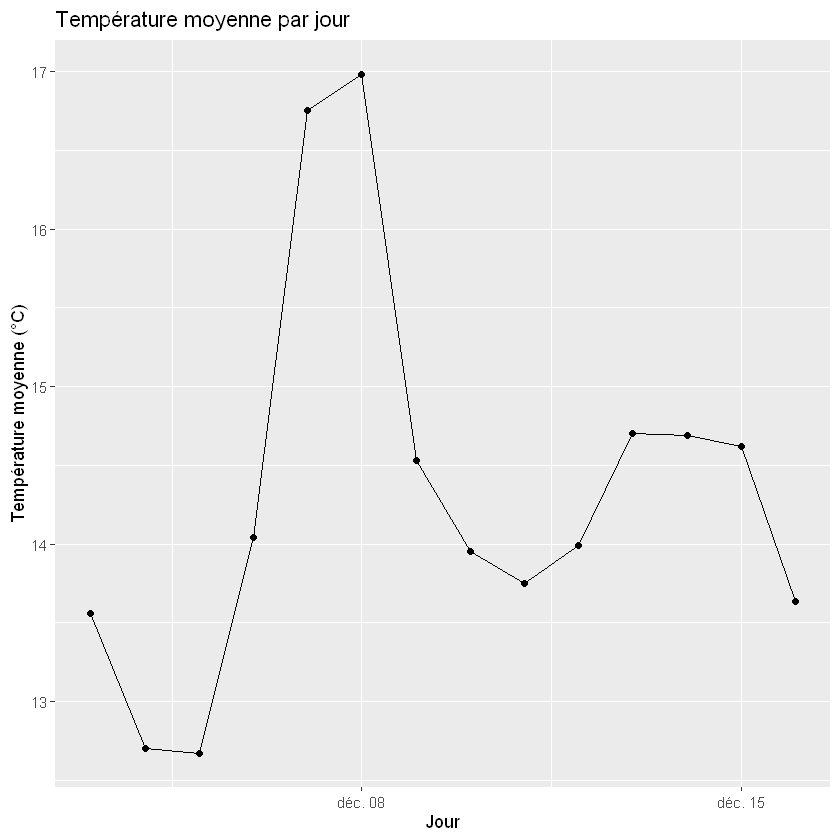

In [9]:
# Température (15 min)
p_temp_15 <- temp_df %>%
  ggplot(aes(x = date, y = valeur)) +
  geom_line() +
  labs(title = "Température (15 min)", x = "Temps", y = "Température (°C)")

p_temp_15
ggsave("output/graphs/temperature_15min.png", p_temp_15, width = 10, height = 4)

# Température moyenne par jour
temp_jour <- temp_df %>%
  mutate(jour = as.Date(date)) %>%
  group_by(jour) %>%
  summarise(temp_moy = mean(valeur, na.rm = TRUE), .groups = "drop")

p_temp_j <- temp_jour %>%
  ggplot(aes(x = jour, y = temp_moy)) +
  geom_line() +
  geom_point() +
  labs(title = "Température moyenne par jour", x = "Jour", y = "Température moyenne (°C)")

p_temp_j
ggsave("output/graphs/temperature_jour.png", p_temp_j, width = 10, height = 4)


### 5.2 Humidité relative : 15 min + moyenne journalière


Warning message in as.POSIXlt.POSIXct(x):
"unknown timezone 'Africa/Tunis'"
Warning message in as.POSIXlt.POSIXct(x):
"unknown timezone 'GMT'"
Warning message in as.POSIXlt.POSIXct(x):
"unknown timezone 'America/New_York'"
Warning message in as.POSIXct.POSIXlt(from):
"unknown timezone 'Africa/Tunis'"
Warning message in as.POSIXct.POSIXlt(from):
"unknown timezone 'GMT'"
Warning message in as.POSIXct.POSIXlt(from):
"unknown timezone 'America/New_York'"
Warning message in as.POSIXct.POSIXlt(from):
"unknown timezone 'Africa/Tunis'"
Warning message in as.POSIXct.POSIXlt(from):
"unknown timezone 'GMT'"
Warning message in as.POSIXct.POSIXlt(from):
"unknown timezone 'America/New_York'"
Warning message in as.POSIXct.POSIXlt(r1):
"unknown timezone 'Africa/Tunis'"
Warning message in as.POSIXct.POSIXlt(r1):
"unknown timezone 'GMT'"
Warning message in as.POSIXct.POSIXlt(r1):
"unknown timezone 'America/New_York'"
Warning message in as.POSIXlt.POSIXct(from):
"unknown timezone 'Africa/Tunis'"
Warning 

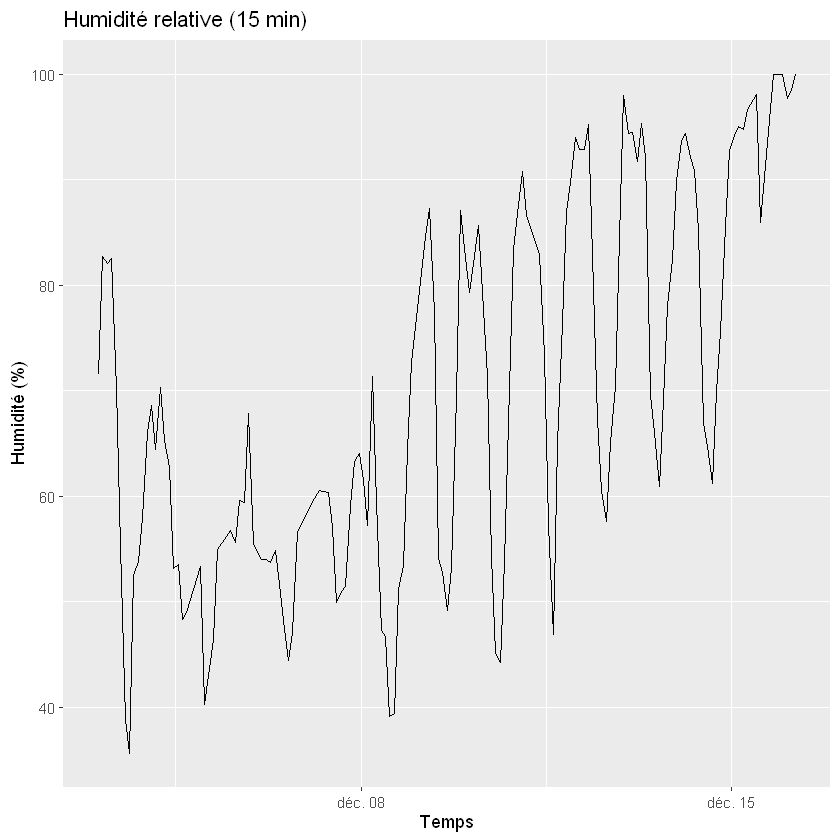

Warning message in as.POSIXlt.POSIXct(x):
"unknown timezone 'Africa/Tunis'"
Warning message in as.POSIXlt.POSIXct(x):
"unknown timezone 'GMT'"
Warning message in as.POSIXlt.POSIXct(x):
"unknown timezone 'America/New_York'"
Warning message in as.POSIXct.POSIXlt(from):
"unknown timezone 'Africa/Tunis'"
Warning message in as.POSIXct.POSIXlt(from):
"unknown timezone 'GMT'"
Warning message in as.POSIXct.POSIXlt(from):
"unknown timezone 'America/New_York'"
Warning message in as.POSIXct.POSIXlt(from):
"unknown timezone 'Africa/Tunis'"
Warning message in as.POSIXct.POSIXlt(from):
"unknown timezone 'GMT'"
Warning message in as.POSIXct.POSIXlt(from):
"unknown timezone 'America/New_York'"
Warning message in as.POSIXct.POSIXlt(r1):
"unknown timezone 'Africa/Tunis'"
Warning message in as.POSIXct.POSIXlt(r1):
"unknown timezone 'GMT'"
Warning message in as.POSIXct.POSIXlt(r1):
"unknown timezone 'America/New_York'"
Warning message in as.POSIXlt.POSIXct(from):
"unknown timezone 'Africa/Tunis'"
Warning 

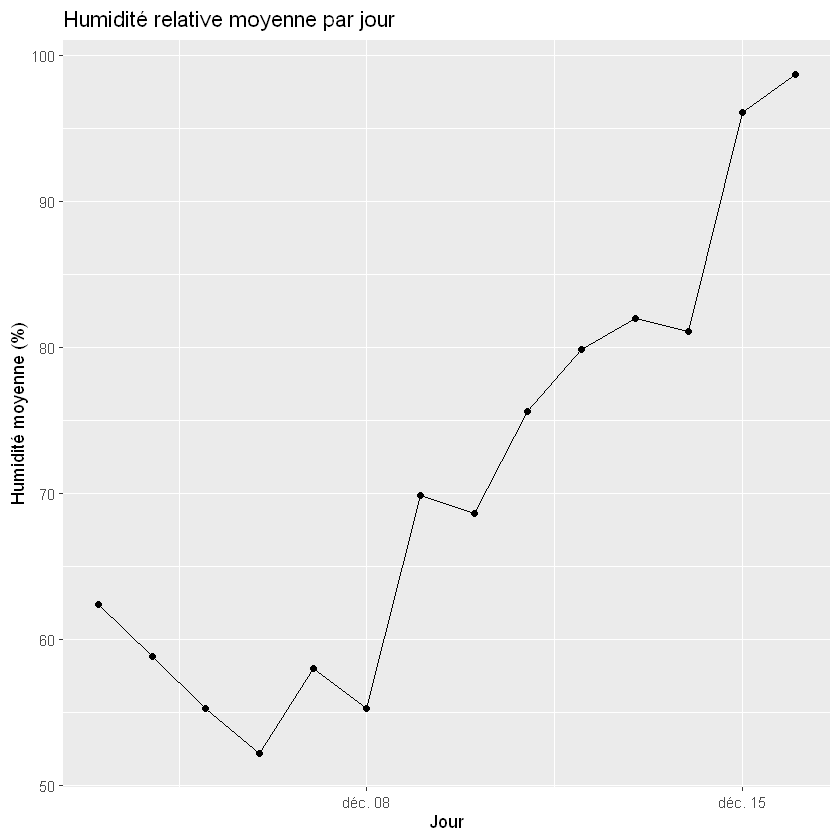

In [10]:
p_hum_15 <- humrel_df %>%
  ggplot(aes(x = date, y = valeur)) +
  geom_line() +
  labs(title = "Humidité relative (15 min)", x = "Temps", y = "Humidité (%)")

p_hum_15
ggsave("output/graphs/humidite_relative_15min.png", p_hum_15, width = 10, height = 4)

hum_jour <- humrel_df %>%
  mutate(jour = as.Date(date)) %>%
  group_by(jour) %>%
  summarise(hum_moy = mean(valeur, na.rm = TRUE), .groups = "drop")

p_hum_j <- hum_jour %>%
  ggplot(aes(x = jour, y = hum_moy)) +
  geom_line() +
  geom_point() +
  labs(title = "Humidité relative moyenne par jour", x = "Jour", y = "Humidité moyenne (%)")

p_hum_j
ggsave("output/graphs/humidite_relative_jour.png", p_hum_j, width = 10, height = 4)


### 5.3 Pluie : total par jour

⚠️ Si tu as un seul jour avec beaucoup de pluie, la barre sera unique (c’est normal).


Warning message in as.POSIXlt.POSIXct(x):
"unknown timezone 'Africa/Tunis'"
Warning message in as.POSIXlt.POSIXct(x):
"unknown timezone 'GMT'"
Warning message in as.POSIXlt.POSIXct(x):
"unknown timezone 'America/New_York'"
Warning message in as.POSIXct.POSIXlt(from):
"unknown timezone 'Africa/Tunis'"
Warning message in as.POSIXct.POSIXlt(from):
"unknown timezone 'GMT'"
Warning message in as.POSIXct.POSIXlt(from):
"unknown timezone 'America/New_York'"
Warning message in as.POSIXct.POSIXlt(from):
"unknown timezone 'Africa/Tunis'"
Warning message in as.POSIXct.POSIXlt(from):
"unknown timezone 'GMT'"
Warning message in as.POSIXct.POSIXlt(from):
"unknown timezone 'America/New_York'"
Warning message in as.POSIXlt.POSIXct(x):
"unknown timezone 'Africa/Tunis'"
Warning message in as.POSIXlt.POSIXct(x):
"unknown timezone 'GMT'"
Warning message in as.POSIXlt.POSIXct(x):
"unknown timezone 'America/New_York'"
Warning message in as.POSIXct.POSIXlt(from):
"unknown timezone 'Africa/Tunis'"
Warning mes

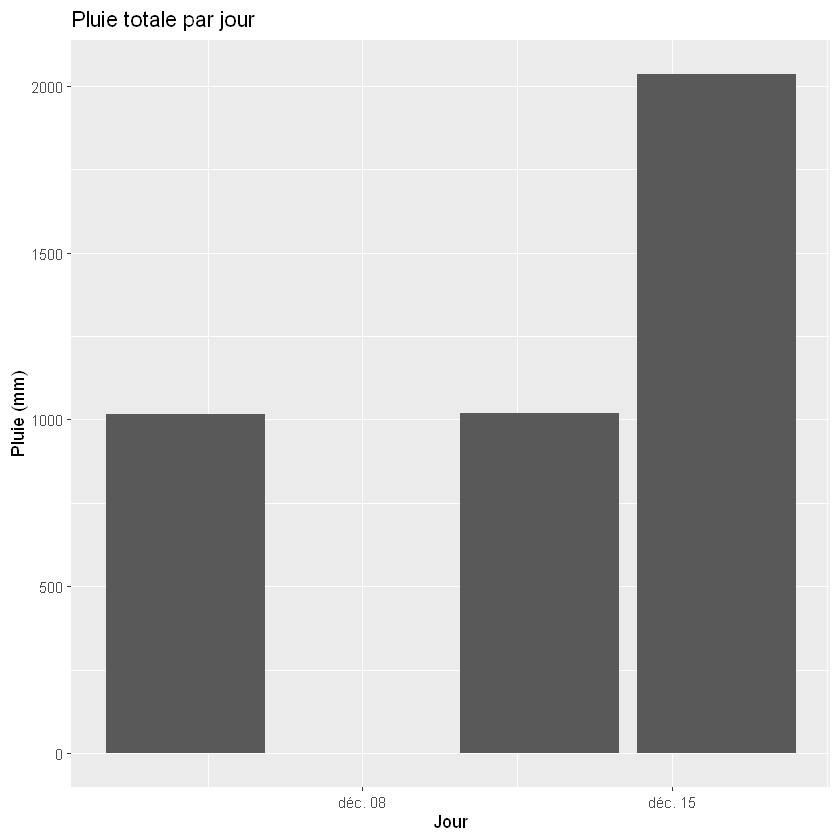

In [11]:
p_pluie <- plui_jour %>%
  ggplot(aes(x = jour, y = pluie_total)) +
  geom_col() +
  labs(title = "Pluie totale par jour", x = "Jour", y = "Pluie (mm)")

p_pluie
ggsave("output/graphs/pluie_par_jour.png", p_pluie, width = 10, height = 4)


### 5.4 Humidité du sol : 10cm vs 30cm (moyenne journalière)

Si les deux courbes se superposent, c’est que les valeurs sont proches.


Warning message in as.POSIXlt.POSIXct(x):
"unknown timezone 'Africa/Tunis'"
Warning message in as.POSIXlt.POSIXct(x):
"unknown timezone 'GMT'"
Warning message in as.POSIXlt.POSIXct(x):
"unknown timezone 'America/New_York'"
Warning message in as.POSIXct.POSIXlt(from):
"unknown timezone 'Africa/Tunis'"
Warning message in as.POSIXct.POSIXlt(from):
"unknown timezone 'GMT'"
Warning message in as.POSIXct.POSIXlt(from):
"unknown timezone 'America/New_York'"
Warning message in as.POSIXct.POSIXlt(from):
"unknown timezone 'Africa/Tunis'"
Warning message in as.POSIXct.POSIXlt(from):
"unknown timezone 'GMT'"
Warning message in as.POSIXct.POSIXlt(from):
"unknown timezone 'America/New_York'"
Warning message in as.POSIXct.POSIXlt(r1):
"unknown timezone 'Africa/Tunis'"
Warning message in as.POSIXct.POSIXlt(r1):
"unknown timezone 'GMT'"
Warning message in as.POSIXct.POSIXlt(r1):
"unknown timezone 'America/New_York'"
Warning message in as.POSIXlt.POSIXct(from):
"unknown timezone 'Africa/Tunis'"
Warning 

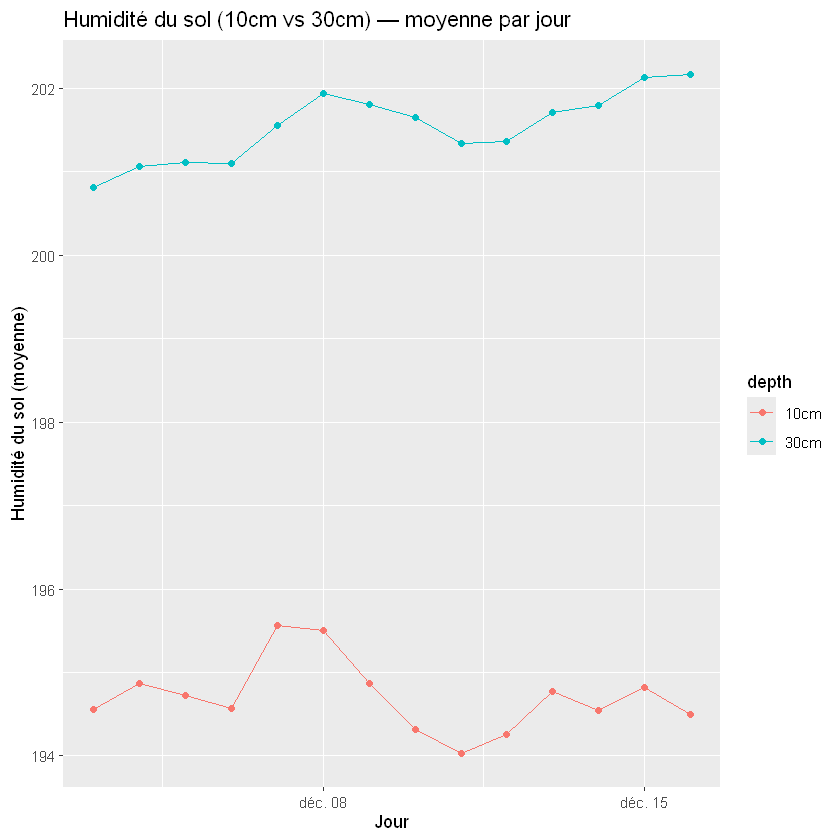

In [12]:
h10_j <- h10 %>%
  mutate(jour = as.Date(date), depth = "10cm") %>%
  group_by(jour, depth) %>%
  summarise(hum_moy = mean(valeur, na.rm = TRUE), .groups = "drop")

h30_j <- h30 %>%
  mutate(jour = as.Date(date), depth = "30cm") %>%
  group_by(jour, depth) %>%
  summarise(hum_moy = mean(valeur, na.rm = TRUE), .groups = "drop")

hum_sol_j <- bind_rows(h10_j, h30_j)

p_sol <- hum_sol_j %>%
  ggplot(aes(x = jour, y = hum_moy, color = depth)) +
  geom_line() +
  geom_point() +
  labs(title = "Humidité du sol (10cm vs 30cm) — moyenne par jour",
       x = "Jour", y = "Humidité du sol (moyenne)")

p_sol
ggsave("output/graphs/humidite_sol_10_vs_30.png", p_sol, width = 10, height = 4)


## 6) Interprétation (texte prêt pour ton rendu)







🌡️ Température

L’analyse de la température montre une tendance générale relativement stable sur la période étudiée, avec des variations journalières marquées. On observe un cycle classique jour/nuit :

des températures plus basses durant la nuit et le matin,

une augmentation progressive en journée, atteignant un maximum l’après-midi.

Ces variations quotidiennes sont typiques des conditions climatiques locales et influencent directement l’évaporation et les besoins en eau des sols et des cultures.

💧 Humidité relative

L’humidité relative présente une évolution souvent inverse à celle de la température :

lorsque la température augmente en journée, l’humidité relative tend à diminuer,

inversement, durant les périodes plus fraîches (nuit et matin), l’humidité relative augmente.

Cette relation inverse est cohérente d’un point de vue physique, car l’air chaud peut contenir plus de vapeur d’eau sans être saturé.

🌧️ Pluviométrie

L’analyse des données de pluie permet d’identifier quelques jours de précipitations, généralement de faible à modérée intensité.
Après ces épisodes pluvieux, on observe une augmentation de l’humidité du sol, ce qui confirme l’impact direct de la pluie sur la recharge hydrique des couches superficielles du sol.

Ces événements jouent un rôle important dans la réduction temporaire du stress hydrique.

🌱 Humidité du sol

L’humidité du sol montre un comportement différent selon la profondeur :

À 10 cm de profondeur :
L’humidité réagit rapidement aux épisodes de pluie et à l’évaporation. On observe des hausses immédiates après la pluie, suivies de baisses rapides en période sèche.
👉 Cette couche est très sensible aux conditions climatiques de surface.

À 30 cm de profondeur :
Les variations sont plus lentes et plus amorties, traduisant une forte inertie du sol.
👉 Cette profondeur reflète davantage l’état hydrique moyen et la réserve en eau du sol.

## 7) Export (optionnel)

Tu peux exporter les séries agrégées pour Power BI / Excel.


In [13]:
write_csv(temp_jour, "output/clean/temperature_jour.csv")
write_csv(hum_jour,  "output/clean/humidite_relative_jour.csv")
write_csv(plui_jour, "output/clean/pluie_jour.csv")
write_csv(hum_sol_j, "output/clean/humidite_sol_jour.csv")

cat("✅ Exports enregistrés dans output/clean/\n")


Warning message in as.POSIXlt.POSIXct(Sys.time(), "UTC"):
"unknown timezone 'Africa/Tunis'"
Warning message in as.POSIXlt.POSIXct(Sys.time(), "UTC"):
"unknown timezone 'GMT'"
Warning message in as.POSIXlt.POSIXct(Sys.time(), "UTC"):
"unknown timezone 'America/New_York'"


✅ Exports enregistrés dans output/clean/
